In [1]:
import cme.decision_models.confidence_accumulation as ca
import numpy as np
import scipy.stats as stats
import pandas as pd
import seaborn as sns
import numpyro as npy
import numpyro.distributions as dist
from cme.utils import common_utils as cu
import jax

In [2]:
np.tile(1,(10,100)).shape

(10, 100)

In [3]:
max_samples, max_RT_sec = 200, 40
I, J = 20, 100
n_states, start_width, delta, measurement_prob,  = 101, 11, 0.5, 0.8
threshold, measurement_prob, drift_rate, diffusion_rate = 1, 1, np.tile(1,(I,1)), np.tile(2,(I,1))
model_type = "Quantum"
transition_type="RT"
phi_0 = ca._get_initial_state(n_states, start_width, model_type=model_type, prior_type="Uniform")
phi_0

Array([[[[0.09950372],
         [0.09950372],
         [0.09950372],
         [0.09950372],
         [0.09950372],
         [0.09950372],
         [0.09950372],
         [0.09950372],
         [0.09950372],
         [0.09950372],
         [0.09950372],
         [0.09950372],
         [0.09950372],
         [0.09950372],
         [0.09950372],
         [0.09950372],
         [0.09950372],
         [0.09950372],
         [0.09950372],
         [0.09950372],
         [0.09950372],
         [0.09950372],
         [0.09950372],
         [0.09950372],
         [0.09950372],
         [0.09950372],
         [0.09950372],
         [0.09950372],
         [0.09950372],
         [0.09950372],
         [0.09950372],
         [0.09950372],
         [0.09950372],
         [0.09950372],
         [0.09950372],
         [0.09950372],
         [0.09950372],
         [0.09950372],
         [0.09950372],
         [0.09950372],
         [0.09950372],
         [0.09950372],
         [0.09950372],
         [0

ca.get_intensity_matrix(n_states, drift_rate, diffusion_rate, model_type=model_type)

In [4]:
def generate_RT(n_states, threshold, delta, measurement_prob, I, J, 
                drift_rate, diffusion_rate, phi_0, max_RT_sec=40, param_sample_id = 1, max_samples=400,
                model_type="Markov|Quantum", transition_type="RT|TIMESTEP", likelihood_type="SINGLE|JOINT",
                keep_incomplete_transitions=False):
    
    def get_RT_frame(I, mu, sigma):
        
        random_ts = dist.Uniform(delta, max_RT_sec/delta).sample(key=cu.get_rng(), sample_shape=(I,max_samples))
        intensity_matrix = ca.get_intensity_matrix(n_states, mu, sigma, model_type=model_type)
        Mc, Mw, Mn = ca._get_measurement_matrix(n_states, threshold, prob=measurement_prob, model_type = model_type)
        phi_t = ca.perform_state_transition(intensity_matrix=intensity_matrix, RT_s = random_ts, RA_s = None, delta=delta, 
                                            Mc = Mc, Mn = Mn, Mw = Mw, phi_0=phi_0, 
                                            transition_type=transition_type, likelihood_type=likelihood_type)

        states_t = dist.Multinomial(total_count=1, probs=phi_t[...,0]).sample(key=cu.get_rng())
        state_final = np.argwhere(states_t)
        RA = np.select([
                state_final[:,[-1]] < threshold - 1,
                state_final[:,[-1]] >= n_states - threshold - 1
            ], [0,1], default = np.nan)#[:,-1]
        Response = np.hstack((state_final, RA, random_ts.flatten()[:,None]*delta))
        df_res = pd.DataFrame(Response, columns=["part_id", "J", "final_state", "RA", "RT"]).assign(param_sample_id=param_sample_id)
        if not keep_incomplete_transitions:
            df_res = df_res.dropna()
        return df_res
    
    df_sample = []
    df_res = get_RT_frame(I, drift_rate, diffusion_rate)
    
    df_sample.append(df_res)
    get_id = (df_res.groupby(["part_id"]).count() < J)[["J"]].query("J == True").index.values.astype(int)
    counter = 0
    while get_id.size != 0 and counter < 2:
        I = get_id.size
        mu, sigma = drift_rate[get_id,...], diffusion_rate[get_id,...]
        df_res = get_RT_frame(I, mu, sigma)
        df_sample.append(df_res)
        counter += 1
        print(f"Retry: {counter}")

    df_sample = pd.concat(df_sample).groupby(["part_id"]).nth(slice(None, J)).rename(columns={"J":"items"})

    return df_sample




In [11]:
df_sample = generate_RT(n_states, threshold, delta, measurement_prob, I, J, 
                drift_rate, diffusion_rate, phi_0, max_RT_sec=max_RT_sec, max_samples=max_samples,
                model_type=model_type, transition_type=transition_type, likelihood_type="SINGLE", 
                keep_incomplete_transitions=False)
df_sample

Retry: 1
Retry: 2


,part_id,state,RA,RT,param_sample_id
0,0.0,99.0,1.0,1.313473,1
3,0.0,99.0,1.0,24.784743,1
8,0.0,100.0,1.0,39.176225,1
11,0.0,100.0,1.0,13.738382,1
12,0.0,99.0,1.0,34.015011,1
...,...,...,...,...,...
3828,19.0,100.0,1.0,25.848500,1
3830,19.0,99.0,1.0,4.805844,1
3832,19.0,99.0,1.0,5.695493,1
3836,19.0,100.0,1.0,3.485762,1


In [12]:
df_sample.groupby(["part_id"]).count()

,state,RA,RT,param_sample_id
part_id,,,,
0.0,100,100,100,100
1.0,100,100,100,100
2.0,100,100,100,100
3.0,100,100,100,100
4.0,100,100,100,100
5.0,100,100,100,100
6.0,100,100,100,100
7.0,100,100,100,100
8.0,100,100,100,100


<Axes: ylabel='Frequency'>

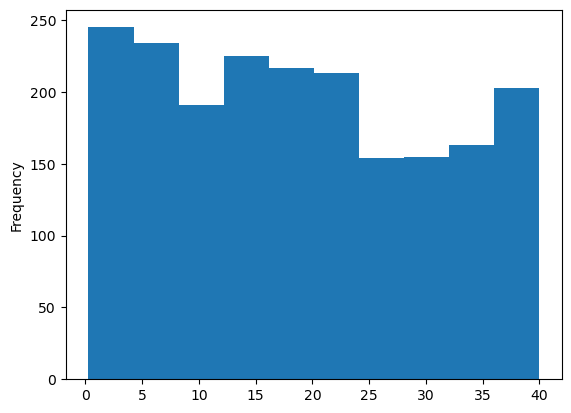

In [14]:
df_sample.RT.plot.hist()